# Project: HR Employee Attrition Analysis 

# Import Data

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns

# Load Data

In [69]:
data = pd.read_excel('C:/Users/JOHN/Desktop/HR Employee Attrition Analysis.xlsx')

In [71]:
data.head()

,EmployeeID,Age,Gender,Department,JobRole,MonthlyIncome,YearsAtCompany,WorkLifeBalance,JobSatisfaction,Attrition
0,1001,53,Female,Finance,Executive,32102.13,0,4,1,No
1,1002,33,Male,HR,Executive,61609.87,1,2,4,Yes
2,1003,39,Female,Finance,Executive,46886.87,6,4,4,No
3,1004,28,Female,Sales,Executive,37200.25,13,2,2,No
4,1005,45,Male,Sales,Analyst,61367.89,6,2,2,Yes


In [73]:
data.info

<bound method DataFrame.info of      EmployeeID  Age  Gender Department    JobRole  MonthlyIncome  \
0          1001   53  Female    Finance  Executive       32102.13   
1          1002   33    Male         HR  Executive       61609.87   
2          1003   39  Female    Finance  Executive       46886.87   
3          1004   28  Female      Sales  Executive       37200.25   
4          1005   45    Male      Sales    Analyst       61367.89   
..          ...  ...     ...        ...        ...            ...   
195        1196   40    Male         IT    Analyst       52688.84   
196        1197   29  Female    Finance      Clerk       44781.82   
197        1198   25  Female      Sales  Executive       43217.18   
198        1199   56    Male    Finance    Analyst       58640.30   
199        1200   34  Female         HR    Analyst       61120.77   

     YearsAtCompany  WorkLifeBalance  JobSatisfaction Attrition  
0                 0                4                1        No  
1      

In [75]:
data.describe()

,EmployeeID,Age,MonthlyIncome,YearsAtCompany,WorkLifeBalance,JobSatisfaction
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,1100.500000,40.235000,49122.395900,7.020000,2.445000,2.595000
std,57.879185,10.718873,16799.702925,4.418963,1.150475,1.139062
min,1001.000000,22.000000,10000.000000,0.000000,1.000000,1.000000
25%,1050.750000,31.000000,36682.347500,3.000000,1.000000,2.000000
50%,1100.500000,40.000000,48234.575000,7.000000,2.000000,3.000000
75%,1150.250000,49.250000,60915.422500,11.000000,3.250000,4.000000
max,1200.000000,59.000000,87382.180000,14.000000,4.000000,4.000000


In [77]:
print(data.dtypes)


EmployeeID           int64
Age                  int64
Gender              object
Department          object
JobRole             object
MonthlyIncome      float64
YearsAtCompany       int64
WorkLifeBalance      int64
JobSatisfaction      int64
Attrition           object
dtype: object


# Attrition by Department

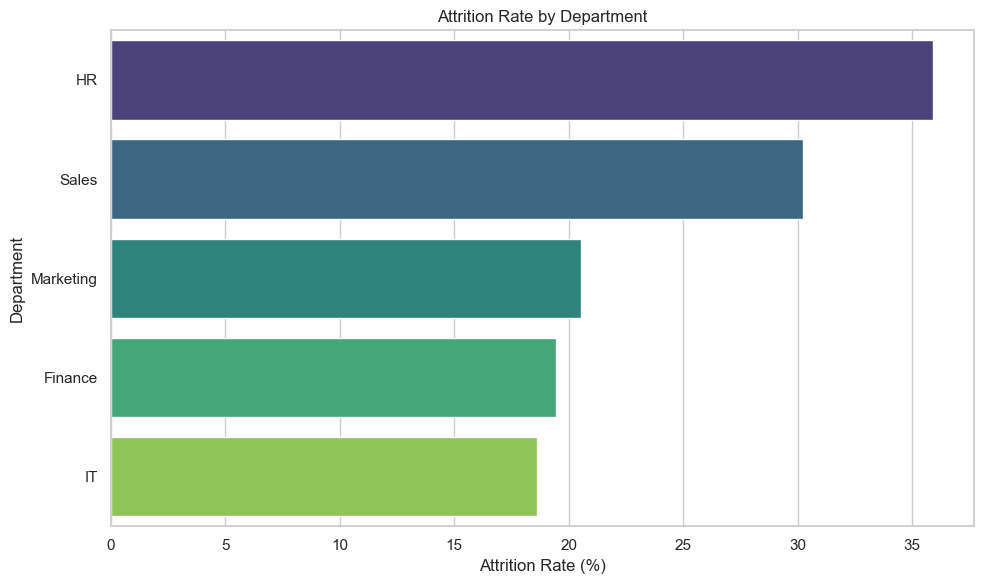

In [80]:

attrition_by_dept = data[data['Attrition'] == 'Yes']['Department'].value_counts()
total_by_dept = data['Department'].value_counts()
attrition_rate_by_dept = (attrition_by_dept / total_by_dept * 100).sort_values(ascending=False)

attrition_df = attrition_rate_by_dept.reset_index()
attrition_df.columns = ['Department', 'AttritionRate']

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.barplot(data=attrition_df, x='AttritionRate', y='Department', hue='Department', palette='viridis', legend=False)
plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


# Monthly Income Distribution

In [83]:
data['MonthlyIncome'] = pd.to_numeric(data['MonthlyIncome'], errors='coerce')

data = data.dropna(subset=['MonthlyIncome', 'Attrition'])

print(data['MonthlyIncome'].dtype)
print(data['Attrition'].unique())


float64
['No' 'Yes']


# Job Satisfaction vs Attrition

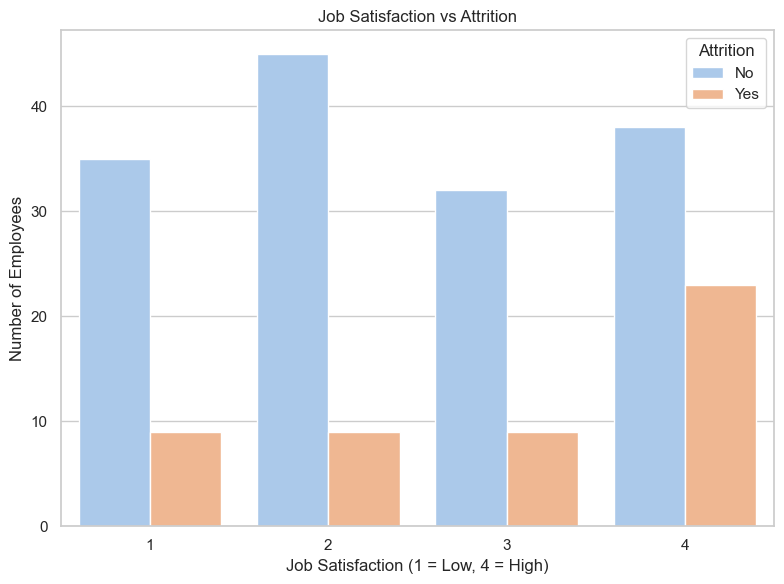

In [86]:
# Plot Job Satisfaction vs Attrition
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")
sns.countplot(data=data, x="JobSatisfaction", hue="Attrition", palette="pastel")
plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction (1 = Low, 4 = High)")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()


# Bonus: Deeper Insights (Optional)

# 1. Attrition vs Years at Company

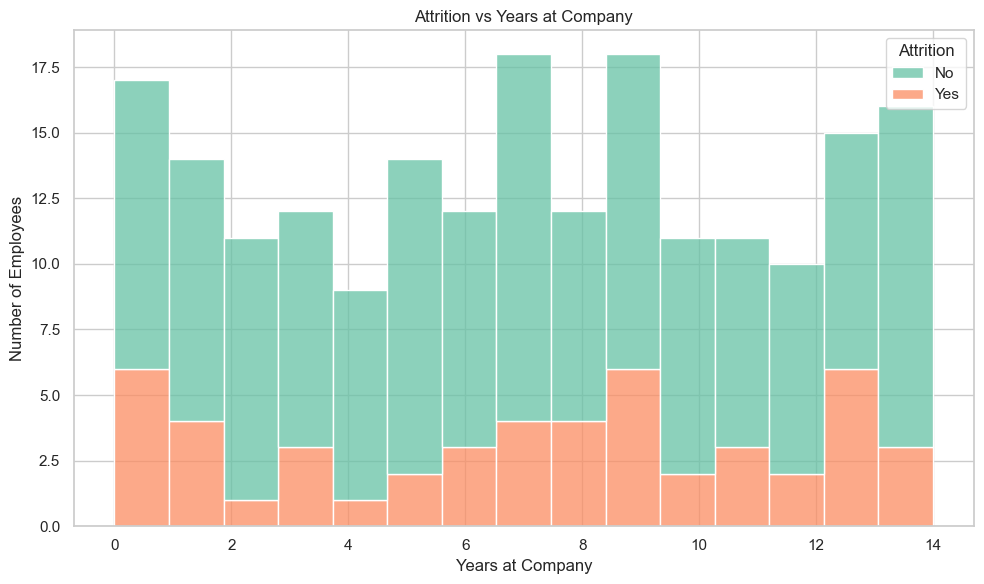

In [90]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="YearsAtCompany", hue="Attrition", multiple="stack", palette="Set2", bins=15)
plt.title("Attrition vs Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()


# 2. Gender-Based Attrition

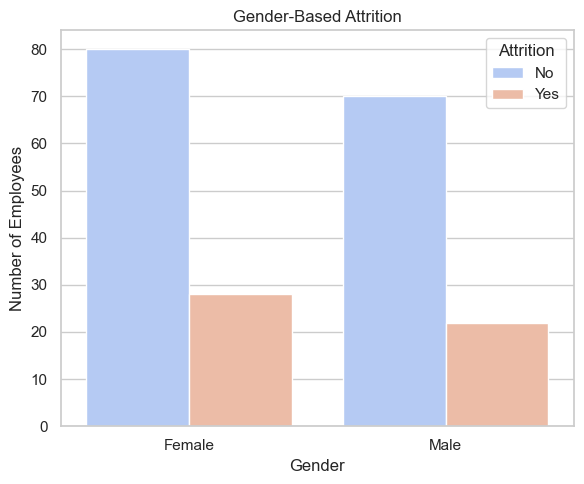

In [93]:
plt.figure(figsize=(6, 5))
sns.countplot(data=data, x="Gender", hue="Attrition", palette="coolwarm")
plt.title("Gender-Based Attrition")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()


# 3. Income vs Work-Life Balance

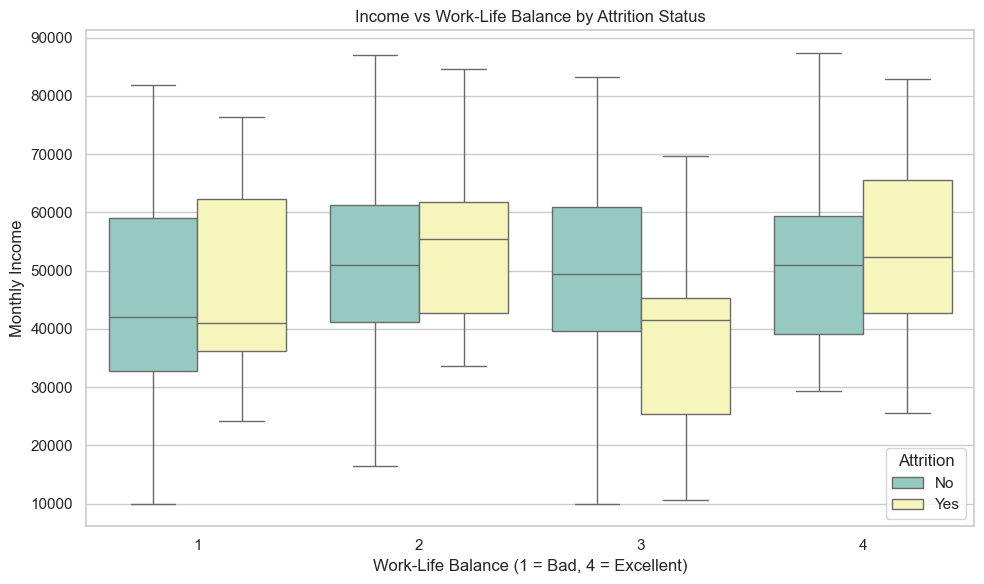

In [96]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="WorkLifeBalance", y="MonthlyIncome", hue="Attrition", palette="Set3")
plt.title("Income vs Work-Life Balance by Attrition Status")
plt.xlabel("Work-Life Balance (1 = Bad, 4 = Excellent)")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()


# Document Your Findings